<a href="https://colab.research.google.com/github/gonida1010/MBT-PyTorch-RAVDESS/blob/main/MBT_PyTorch_RAVDESS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# https://www.kaggle.com/datasets/orvile/ravdess-dataset
# 배우 감정 데이터셋 활용

In [1]:
!pip install -q kaggle

In [2]:
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d orvile/ravdess-dataset
!unzip -q ravdess-dataset.zip -d ravdess_data

Dataset URL: https://www.kaggle.com/datasets/orvile/ravdess-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 23.8G/23.9G [01:03<00:00, 336MB/s]
100% 23.9G/23.9G [01:03<00:00, 401MB/s]


In [5]:
!pip install -q librosa opencv-python torchaudio

import os
import cv2
import librosa
import numpy as np
import torch
import torchaudio
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [6]:
def extract_video_frames(video_path, num_frames=16, resize=(224, 224)):
    """
    비디오에서 프레임을 추출하고 텐서로 변환합니다.
    """
    cap = cv2.VideoCapture(video_path)
    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # 균일한 간격으로 프레임 추출
    if total_frames > 0:
        step = max(total_frames // num_frames, 1)
        for i in range(total_frames):
            ret, frame = cap.read()
            if not ret:
                break
            if i % step == 0 and len(frames) < num_frames:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = cv2.resize(frame, resize)
                frames.append(frame)
    cap.release()

    while len(frames) < num_frames:
        if frames:
            frames.append(frames[-1])
        else:
            frames.append(np.zeros((*resize, 3), dtype=np.uint8))

    # [Frames, H, W, C] -> [Frames, C, H, W]로 변경 및 정규화
    frames = np.array(frames)
    frames = np.transpose(frames, (0, 3, 1, 2))
    tensor_frames = torch.tensor(frames, dtype=torch.float32) / 255.0

    return tensor_frames

In [17]:
import warnings
# librosa에서 발생하는 잡다한 UserWarning 무시
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

def extract_audio_spectrogram(video_path, target_sr=16000, n_mels=128, max_time_steps=128):
    """
    비디오 파일에서 오디오를 추출하여 멜 스펙트로그램 텐서로 변환합니다.
    """
    try:
        # librosa는 영상 파일의 오디오 트랙도 바로 읽을 수 있습니다.
        audio, sr = librosa.load(video_path, sr=target_sr)
    except Exception as e:
        # 오디오 트랙이 손상되거나 없는 경우 빈 배열 반환
        audio = np.zeros(target_sr)
        sr = target_sr

    # Mel Spectrogram 생성
    mel_spectrogram = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=n_mels)
    log_mel = librosa.power_to_db(mel_spectrogram, ref=np.max)

    # 시퀀스 길이(Time steps) 맞추기
    if log_mel.shape[1] < max_time_steps:
        # 길이가 짧으면 패딩
        pad_width = max_time_steps - log_mel.shape[1]
        log_mel = np.pad(log_mel, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        # 길이가 길면 자르기
        log_mel = log_mel[:, :max_time_steps]

    # 채널 차원 추가 [1, Mels, Time]
    tensor_audio = torch.tensor(log_mel, dtype=torch.float32).unsqueeze(0)

    return tensor_audio

In [18]:
class RAVDESSMultimodalDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.file_paths = []
        self.labels = []

        # RAVDESS 파일명 규칙: 03-01-06-01-02-01-12.mp4
        # 3번째 식별자가 감정(Emotion)을 나타냄 (01=neutral, 02=calm, 03=happy, 04=sad, 05=angry, 06=fearful, 07=disgust, 08=surprised)
        for root, _, files in os.walk(root_dir):
            for file in files:
                if file.endswith('.mp4'):
                    path = os.path.join(root, file)
                    parts = file.split('-')
                    if len(parts) == 7:
                        # 감정 라벨 추출 (0부터 시작하도록 -1)
                        emotion = int(parts[2]) - 1
                        self.file_paths.append(path)
                        self.labels.append(emotion)

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        video_path = self.file_paths[idx]
        label = self.labels[idx]

        vision_tensor = extract_video_frames(video_path)
        audio_tensor = extract_audio_spectrogram(video_path)
        label_tensor = torch.tensor(label, dtype=torch.long)

        return vision_tensor, audio_tensor, label_tensor

In [30]:
dataset_path = "ravdess_data"
multimodal_dataset = RAVDESSMultimodalDataset(root_dir=dataset_path)

print(f"총 로드된 멀티모달 데이터 개수: {len(multimodal_dataset)}개")

num_cores = os.cpu_count()
print(f"사용 가능한 CPU 코어 수: {num_cores}")

dataloader = DataLoader(
    multimodal_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=12,
    pin_memory=True,
    prefetch_factor=2
)


for vision_batch, audio_batch, label_batch in dataloader:
    print("--- Shape 확인 ---")
    print(f"Vision 텐서 (비디오): {vision_batch.shape} # [Batch, Frames, Channels, Height, Width]")
    print(f"Audio 텐서 (스펙트로그램): {audio_batch.shape} # [Batch, Channels, Mels, TimeSteps]")
    print(f"Label 텐서 (감정): {label_batch.shape}")
    break

총 로드된 멀티모달 데이터 개수: 4904개
사용 가능한 CPU 코어 수: 12
--- Shape 확인 ---
Vision 텐서 (비디오): torch.Size([64, 16, 3, 224, 224]) # [Batch, Frames, Channels, Height, Width]
Audio 텐서 (스펙트로그램): torch.Size([64, 1, 128, 128]) # [Batch, Channels, Mels, TimeSteps]
Label 텐서 (감정): torch.Size([64])


In [31]:
import torch
import torch.nn as nn
import torchvision.models as models

In [32]:
class SimpleMBT(nn.Module):
    def __init__(self, num_classes=8, d_model=256, nhead=4, num_layers=4, fusion_layer=2, bottleneck_size=4):
        super(SimpleMBT, self).__init__()
        self.d_model = d_model
        self.fusion_layer = fusion_layer
        self.bottleneck_size = bottleneck_size

        # 1. 특징 추출기
        # 시각: ResNet18을 사용해 각 프레임을 d_model 크기의 벡터로 압축
        resnet = models.resnet18(pretrained=True)
        self.vision_extractor = nn.Sequential(
            *list(resnet.children())[:-1],
            nn.Flatten(),
            nn.Linear(512, d_model)
        )

        # 청각: Conv2d를 이용한 Patch Embedding
        # 입력 [B, 1, 128, 128] -> 출력 [B, d_model, 15, 15]
        self.audio_proj = nn.Conv2d(1, d_model, kernel_size=(16, 16), stride=(8, 8))

        # 2. 병목 토큰 (학습 가능한 파라미터)
        self.bottleneck_tokens = nn.Parameter(torch.randn(1, bottleneck_size, d_model))

        # 3. 트랜스포머 인코더 레이어 (시각, 청각 각각 구성)
        self.vision_transformers = nn.ModuleList([
            nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
            for _ in range(num_layers)
        ])
        self.audio_transformers = nn.ModuleList([
            nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
            for _ in range(num_layers)
        ])

        # 4. 최종 분류기 (Classifier)
        self.classifier = nn.Sequential(
            nn.Linear(d_model * 2, d_model),
            nn.ReLU(),
            nn.Linear(d_model, num_classes)
        )

    def forward(self, vision_x, audio_x):
        batch_size = vision_x.size(0)

        # 특징 추출
        # Vision: [B, Frames, C, H, W] -> [B, Frames, d_model]
        frames = vision_x.size(1)
        vision_x = vision_x.view(batch_size * frames, 3, 224, 224)
        v_tokens = self.vision_extractor(vision_x)
        v_tokens = v_tokens.view(batch_size, frames, self.d_model)

        # Audio: [B, 1, 128, 128] -> [B, Time_Tokens, d_model]
        a_tokens = self.audio_proj(audio_x)            # [B, 256, 15, 15]
        a_tokens = a_tokens.flatten(2)                 # [B, 256, 225] (공간/시간 차원 병합)
        a_tokens = a_tokens.transpose(1, 2)            # [B, 225, 256] (Transformer 입력 규격에 맞게 Transpose)

        # 배치 크기에 맞게 병목 토큰 확장
        b_tokens = self.bottleneck_tokens.expand(batch_size, -1, -1)

        # 트랜스포머 및 병목 융합
        for i in range(len(self.vision_transformers)):
            if i < self.fusion_layer:
                # Early phase: 유니모달 (각자 독립적으로 어텐션 수행)
                v_tokens = self.vision_transformers[i](v_tokens)
                a_tokens = self.audio_transformers[i](a_tokens)
            else:
                # Mid-fusion phase: 병목 토큰을 이어 붙여 정보 교환
                v_input = torch.cat([v_tokens, b_tokens], dim=1)
                a_input = torch.cat([a_tokens, b_tokens], dim=1)

                v_out = self.vision_transformers[i](v_input)
                a_out = self.audio_transformers[i](a_input)

                # 토큰 분리 (원래 모달리티 토큰 + 업데이트된 임시 병목 토큰)
                v_tokens = v_out[:, :-self.bottleneck_size, :]
                v_b_out = v_out[:, -self.bottleneck_size:, :]

                a_tokens = a_out[:, :-self.bottleneck_size, :]
                a_b_out = a_out[:, -self.bottleneck_size:, :]

                # 병목 토큰 대칭 업데이트 (평균)
                b_tokens = (v_b_out + a_b_out) / 2.0

        # 최종 분류
        # 각 모달리티의 평균 벡터(Global Average Pooling)를 구하여 결합
        v_cls = v_tokens.mean(dim=1)
        a_cls = a_tokens.mean(dim=1)

        fused_representation = torch.cat([v_cls, a_cls], dim=1)
        logits = self.classifier(fused_representation)

        return logits

In [33]:
# 디바이스 설정 (GPU가 있으면 GPU 사용)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# 하이퍼파라미터
num_epochs = 10
learning_rate = 1e-4

# 모델 생성 및 디바이스 이동 (RAVDESS 감정 클래스 8개)
model = SimpleMBT(num_classes=8, d_model=256, nhead=4, num_layers=4, fusion_layer=2).to(device)

# 손실 함수 및 최적화 함수
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

cuda


In [35]:
save_dir = "ravdess_preprocessed"
os.makedirs(save_dir, exist_ok=True)

for i in tqdm(range(len(multimodal_dataset))):
    vision_tensor, audio_tensor, label_tensor = multimodal_dataset[i]

    save_path = os.path.join(save_dir, f"data_{i}.pt")
    torch.save({
        'vision': vision_tensor,
        'audio': audio_tensor,
        'label': label_tensor
    }, save_path)

print("모든 데이터 텐서 변환 및 저장")

100%|██████████| 4904/4904 [31:10<00:00,  2.62it/s]

모든 데이터 텐서 변환 및 저장


In [36]:
from torch.utils.data import Dataset, DataLoader

class FastRAVDESSDataset(Dataset):
    def __init__(self, preprocessed_dir):
        # 디렉토리 내의 모든 .pt 파일 경로를 리스트로 저장
        self.file_paths = [os.path.join(preprocessed_dir, f) for f in os.listdir(preprocessed_dir) if f.endswith('.pt')]

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        # MP4 디코딩 없이, 이미 완성된 텐서를 디스크에서 바로 로드 (초고속)
        data = torch.load(self.file_paths[idx], weights_only=True)
        return data['vision'], data['audio'], data['label']

# 3. 새로운 고속 Dataset과 Dataloader 적용
fast_dataset = FastRAVDESSDataset(save_dir)

# A100의 스펙을 100% 활용하는 세팅
fast_dataloader = DataLoader(
    fast_dataset,
    batch_size=64,        # VRAM 여유에 따라 128로 올려도 무방합니다.
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

print(f"총 배치 개수: {len(fast_dataloader)}")

고속 데이터로더 준비 완료. 총 배치 개수: 77


In [37]:
from tqdm import tqdm

train_loader = fast_dataloader

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

    for vision_batch, audio_batch, label_batch in progress_bar:
        vision_batch = vision_batch.to(device)
        audio_batch = audio_batch.to(device)
        label_batch = label_batch.to(device)

        # 1. Forward Pass
        outputs = model(vision_batch, audio_batch)
        loss = criterion(outputs, label_batch)

        # 2. Backward Pass & Optimization
        optimizer.zero_grad() # 기울기 초기화
        loss.backward()       # 역전파
        optimizer.step()      # 가중치 업데이트

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += label_batch.size(0)
        correct += (predicted == label_batch).sum().item()
        progress_bar.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    print(f"[Epoch {epoch+1}] Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")

Epoch 1/10: 100%|██████████| 77/77 [00:37<00:00,  2.03it/s, loss=0.34]


[Epoch 1] Loss: 0.5081, Accuracy: 84.91%


Epoch 2/10: 100%|██████████| 77/77 [00:37<00:00,  2.03it/s, loss=0.106]


[Epoch 2] Loss: 0.1584, Accuracy: 95.47%


Epoch 3/10: 100%|██████████| 77/77 [00:37<00:00,  2.04it/s, loss=0.0552]


...

[Epoch 8] Loss: 0.0296, Accuracy: 99.27%


Epoch 9/10: 100%|██████████| 77/77 [00:37<00:00,  2.04it/s, loss=0.00769]


[Epoch 9] Loss: 0.0240, Accuracy: 99.35%


Epoch 10/10: 100%|██████████| 77/77 [00:37<00:00,  2.03it/s, loss=0.00503]

[Epoch 10] Loss: 0.0260, Accuracy: 99.18%


In [38]:
def evaluate_model(model, test_loader):
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for vision_batch, audio_batch, label_batch in test_loader:
            vision_batch = vision_batch.to(device)
            audio_batch = audio_batch.to(device)
            label_batch = label_batch.to(device)

            outputs = model(vision_batch, audio_batch)
            loss = criterion(outputs, label_batch)

            test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += label_batch.size(0)
            correct += (predicted == label_batch).sum().item()

    final_loss = test_loss / len(test_loader)
    final_acc = 100 * correct / total

    print(f"Test Loss: {final_loss:.4f}")
    print(f"Test Accuracy: {final_acc:.2f}%")

--- 시각적 검증 테스트 ---


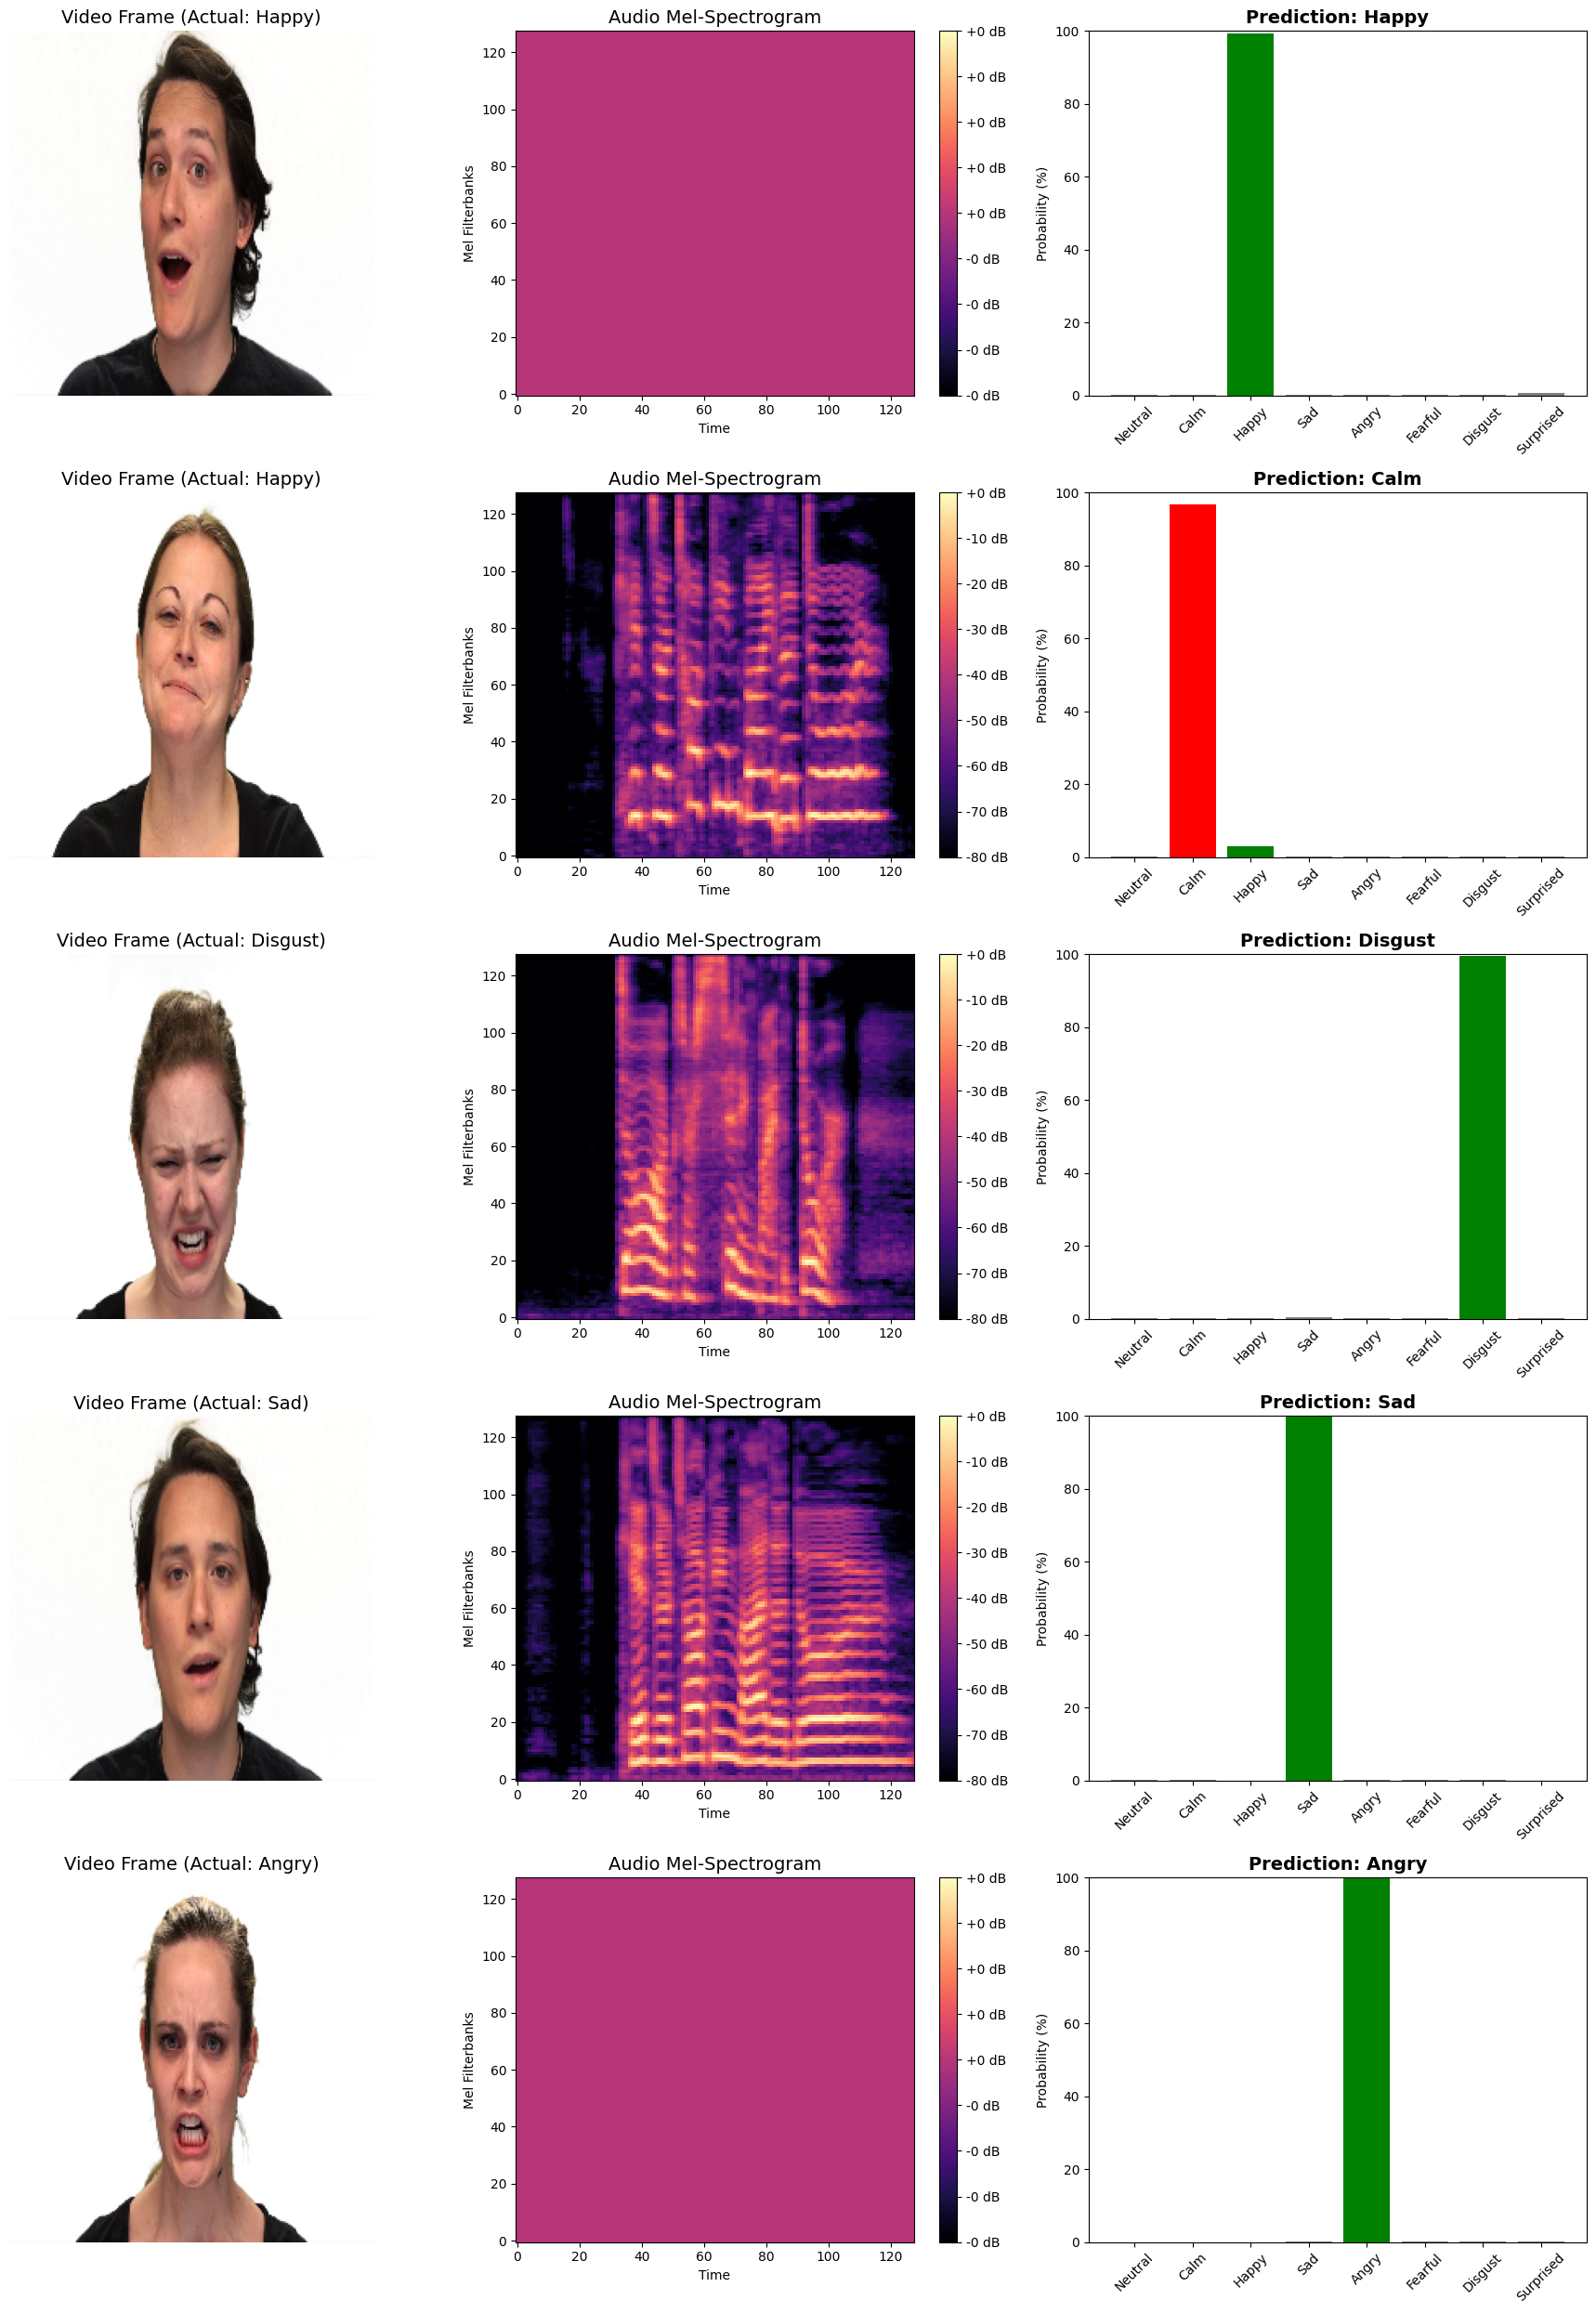

In [43]:
import matplotlib.pyplot as plt
import torch.nn.functional as F
import random

emotion_map = {
    0: 'Neutral',           # 중립
    1: 'Calm',              # 평온
    2: 'Happy',             # 행복
    3: 'Sad',               # 슬픔
    4: 'Angry',             # 분노
    5: 'Fearful',           # 두려움
    6: 'Disgust',           # 혐오
    7: 'Surprised'          # 놀람
}

def visualize_multiple_predictions(model, dataset, device, num_samples=5):
    """
    지정된 개수의 랜덤 데이터를 모델에 통과시키고,
    시각/청각 데이터와 예측 확률을 여러 줄로 시각화합니다.
    """
    model.eval()

    indices = random.sample(range(len(dataset)), num_samples)

    # 5행 3열의 그래프 세팅
    fig, axes = plt.subplots(num_samples, 3, figsize=(18, 5 * num_samples))

    for row, idx in enumerate(indices):
        vision_tensor, audio_tensor, label_tensor = dataset[idx]
        actual_emotion = emotion_map[label_tensor.item()]

        v_input = vision_tensor.unsqueeze(0).to(device)
        a_input = audio_tensor.unsqueeze(0).to(device)

        # 추론
        with torch.no_grad():
            logits = model(v_input, a_input)
            probabilities = F.softmax(logits, dim=1).squeeze().cpu().numpy()

        predicted_class = probabilities.argmax()
        predicted_emotion = emotion_map[predicted_class]

        # 1. 비디오 프레임 시각화
        mid_frame_idx = vision_tensor.shape[0] // 2
        img_to_show = vision_tensor[mid_frame_idx].permute(1, 2, 0).numpy()
        axes[row, 0].imshow(img_to_show)
        axes[row, 0].set_title(f"Video Frame (Actual: {actual_emotion})", fontsize=14)
        axes[row, 0].axis('off')

        # 2. 오디오 스펙트로그램 시각화
        spec_to_show = audio_tensor.squeeze(0).numpy()
        cax = axes[row, 1].imshow(spec_to_show, aspect='auto', origin='lower', cmap='magma')
        axes[row, 1].set_title("Audio Mel-Spectrogram", fontsize=14)
        axes[row, 1].set_xlabel("Time")
        axes[row, 1].set_ylabel("Mel Filterbanks")
        fig.colorbar(cax, ax=axes[row, 1], format="%+2.0f dB")

        # 3. 모델 예측 확률
        emotions = [emotion_map[i] for i in range(8)]
        colors = ['green' if i == label_tensor.item() else 'gray' for i in range(8)]
        if predicted_class != label_tensor.item():
            colors[predicted_class] = 'red'

        axes[row, 2].bar(emotions, probabilities * 100, color=colors)
        axes[row, 2].set_title(f"Prediction: {predicted_emotion}", fontsize=14, fontweight='bold')
        axes[row, 2].set_ylabel("Probability (%)")
        axes[row, 2].set_ylim(0, 100)
        axes[row, 2].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

print("--- 시각적 검증 테스트 ---")
visualize_multiple_predictions(model, multimodal_dataset, device, num_samples=5)